# How to read Matplotlib plots

**Thời gian ước tính / Estimated time:** 15–20 phút

Notebook này là hướng dẫn **chung**: nhìn từng loại hình rồi viết nhận xét. Áp dụng cho **mọi dataset**, không gắn với một bài lab cụ thể. Khi nhận xét, đừng kể lại lệnh vẽ. Viết: (1) nhìn thấy gì, (2) điều đó nói gì về biến đang xét, (3) có bất thường / hạn chế không.

This notebook is a **general** guide to reading plots and writing comments. It applies to **any dataset**, not one lab. Do not restate plotting code. Write: (1) what you see, (2) what it means, (3) any odd pattern or limitation.

## Mục tiêu / Objectives

* Phân biệt **line, scatter, bar/barh, histogram, subplots** khi đọc hình
* Có checklist để viết conclusion
* Chạy vài ví dụ dữ liệu giả để thấy từng dạng


## Mục lục / Table of Contents

1. [Line plot](#line)
2. [Scatter plot](#scatter)
3. [Bar / barh](#bar)
4. [Histogram](#hist)
5. [Subplots](#subplots)
6. [Khung viết nhận xét / Writing template](#khung)


Chạy cell này một lần. Các ví dụ bên dưới dùng **số giả**, chỉ để minh họa cách nhìn.

Run this cell once. Examples below use **toy numbers**, only to illustrate how to read the figure.


In [23]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(0)


## 1. Line plot <a id="line"></a>

Dùng khi trục x có **thứ tự** (thời gian, bước, chỉ số, tuổi, …). Đọc **từ trái sang phải**.

Use a line when x is ordered. Read **left to right**.

| Nhìn gì / What to look for | Ý nghĩa / Meaning |
|---|---|
| Đi lên / lên dốc | y **tăng** theo x |
| Đi xuống | y **giảm** theo x |
| Gần nằm ngang | ít xu hướng / ổn định |
| Đều, gần thẳng | quan hệ gần tuyến tính |
| Đỉnh, đáy, đoạn nhảy | không đều; có gãy hoặc sự kiện |
| Nhiều đường: cái nào cao hơn? cắt nhau? | so sánh nhóm; thứ hạng có đổi không |

**Câu mẫu / Example:** “Y tăng theo X nhưng không đều, có một đoạn giảm giữa chừng, nên quan hệ không phải đường thẳng đơn giản.”


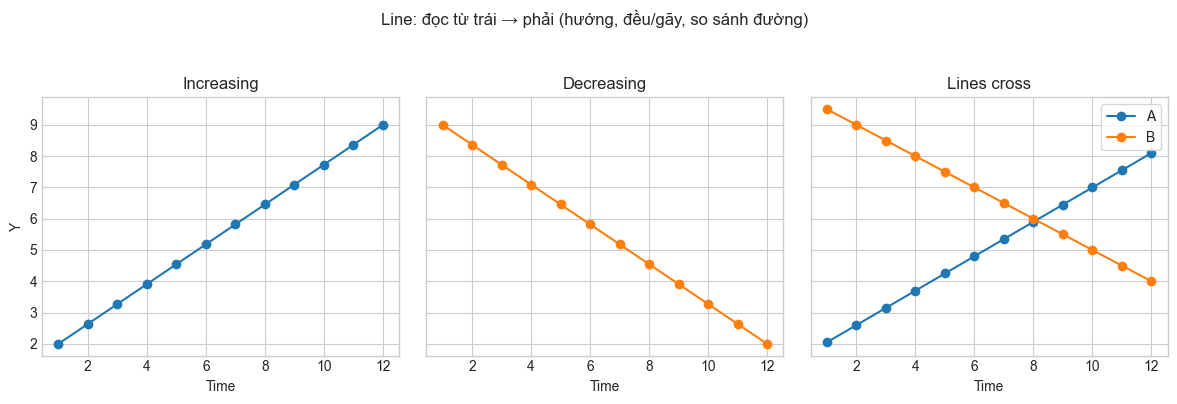

In [24]:
# Ba dạng chuẩn: tăng / giảm / hai đường cắt nhau
x = np.arange(1, 13)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)

axes[0].plot(x, np.linspace(2, 9, 12), marker="o", color="C0")
axes[0].set(title="Increasing", xlabel="Time", ylabel="Y")

axes[1].plot(x, np.linspace(9, 2, 12), marker="o", color="C1")
axes[1].set(title="Decreasing", xlabel="Time")

axes[2].plot(x, 1.5 + 0.55 * x, marker="o", label="A")
axes[2].plot(x, 10 - 0.50 * x, marker="o", label="B")
axes[2].legend(frameon=True)
axes[2].set(title="Lines cross", xlabel="Time")

fig.suptitle("Line: đọc từ trái → phải (hướng, đều/gãy, so sánh đường)", y=1.05)
fig.tight_layout()
plt.show()


**Đọc hình / How to read it**

* Trái: Y **tăng** đều theo thời gian (gần tuyến tính).
* Giữa: Y **giảm** đều.
* Phải: A đi lên, B đi xuống, **cắt nhau** — nửa đầu B cao hơn, nửa sau A cao hơn.

Left: steadily up. Middle: steadily down. Right: A rises, B falls, they **cross**.


## 2. Scatter plot <a id="scatter"></a>

Mỗi **chấm** = một dòng dữ liệu. Các chấm **không nối** bằng đường — khác line plot.

Each **dot** is one row. Dots are **not connected**.

### Cách đọc

**Bước 1.** Một chấm = một cặp `(X, Y)`.

**Bước 2.** So sánh phía **trái** (X nhỏ) với phía **phải** (X lớn): Y cao hơn, thấp hơn, hay loạn?

`corr` là **một con số** tóm tắt mối quan hệ tuyến tính giữa X và Y, luôn nằm trong **[−1, 1]**:

| `corr` | Ý nghĩa |
|---|---|
| gần **+1** | cùng chiều và **chặt** (chấm bám sát một đường thẳng đi lên) |
| dương, ví dụ 0.6 | cùng chiều nhưng **còn rải** |
| gần **0** | gần như không đoán Y từ X |
| gần **−1** | ngược chiều và chặt (đường thẳng đi xuống) |

Hình 4 bên dưới vẽ thêm **đường thẳng khớp nhất** và in `corr` để thấy số này đi với hình như thế nào. `corr` **không** nói X gây ra Y.

`corr` is a single number in [−1, 1]. Figure 4 adds a best-fit line so you can see the number and the cloud together. It is not causation.


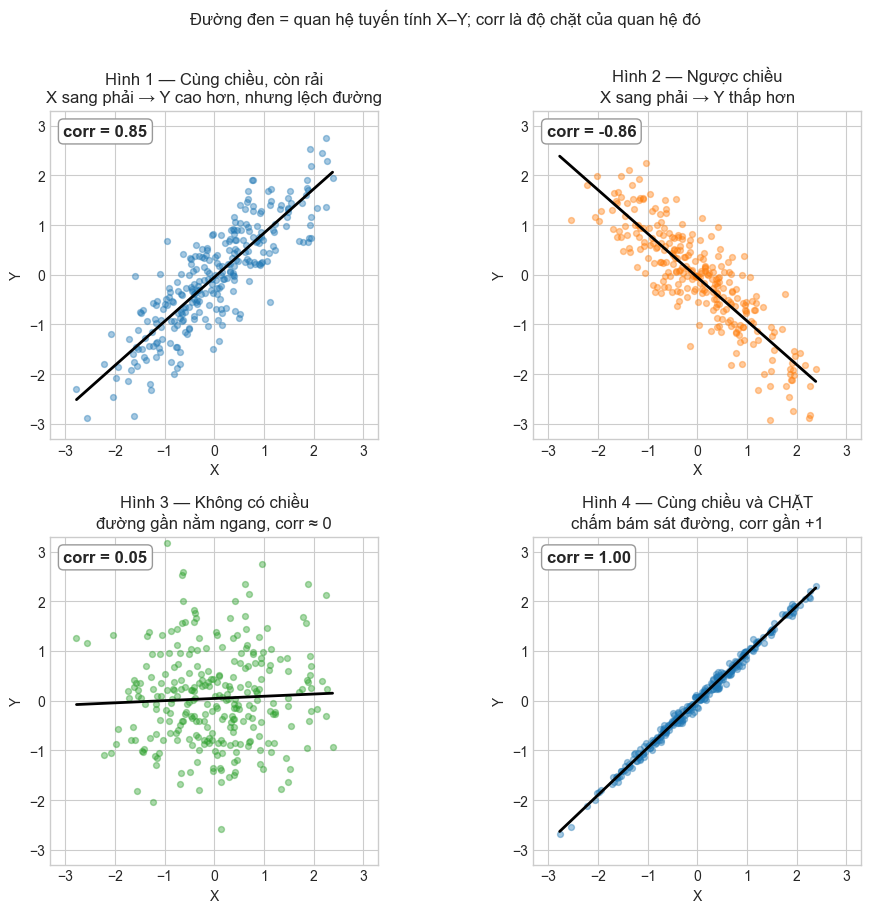

In [25]:
def ve_scatter_va_corr(ax, x, y, mau="C0"):
    ax.scatter(x, y, alpha=0.4, s=18, color=mau)
    r = float(np.corrcoef(x, y)[0, 1])
    a, b = np.polyfit(x, y, 1)  # Y ≈ a*X + b
    xs = np.array([x.min(), x.max()])
    ax.plot(xs, a * xs + b, color="black", lw=2)
    ax.text(
        0.04, 0.96, f"corr = {r:.2f}",
        transform=ax.transAxes, va="top",
        fontsize=12, fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"),
    )
    return r

n = 280
x = np.random.normal(0, 1, n)
y1 = 0.85 * x + np.random.normal(0, 0.55, n)   # cùng chiều, còn rải
y2 = -0.85 * x + np.random.normal(0, 0.55, n)  # ngược chiều
y3 = np.random.normal(0, 1, n)                 # không liên quan
y4 = 0.95 * x + np.random.normal(0, 0.08, n)   # cùng chiều, rất chặt

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

ve_scatter_va_corr(axes[0, 0], x, y1, "C0")
axes[0, 0].set(title="Hình 1 — Cùng chiều, còn rải\nX sang phải → Y cao hơn, nhưng lệch đường",
               xlabel="X", ylabel="Y")

ve_scatter_va_corr(axes[0, 1], x, y2, "C1")
axes[0, 1].set(title="Hình 2 — Ngược chiều\nX sang phải → Y thấp hơn",
               xlabel="X", ylabel="Y")

ve_scatter_va_corr(axes[1, 0], x, y3, "C2")
axes[1, 0].set(title="Hình 3 — Không có chiều\nđường gần nằm ngang, corr ≈ 0",
               xlabel="X", ylabel="Y")

ve_scatter_va_corr(axes[1, 1], x, y4, "C0")
axes[1, 1].set(title="Hình 4 — Cùng chiều và CHẶT\nchấm bám sát đường, corr gần +1",
               xlabel="X", ylabel="Y")

for ax in axes.ravel():
    ax.set_xlim(-3.3, 3.3)
    ax.set_ylim(-3.3, 3.3)
    ax.set_aspect("equal", adjustable="box")

fig.suptitle("Đường đen = quan hệ tuyến tính X–Y; corr là độ chặt của quan hệ đó", y=1.01)
fig.tight_layout()
plt.show()


**Đọc 4 hình**

Hỏi: *X sang phải thì Y thế nào?* Rồi nhìn số **corr** và đường đen.

1. **Hình 1:** cùng chiều nhưng chấm **lệch đường** → `corr` dương, chưa gần 1.
2. **Hình 2:** ngược chiều → `corr` **âm**.
3. **Hình 3:** đường gần **nằm ngang**, chấm loạn → `corr` ≈ **0** (X và Y gần như không đi cùng nhau).
4. **Hình 4:** cùng chiều và chấm **bám sát đường thẳng** → `corr` gần **+1**. Đây là lúc “X và Y có mối quan hệ tuyến tính chặt”.

Cùng chiều (hình 1 và 4) vẫn khác nhau: **hướng** giống, **độ chặt** khác — đó chính là `corr`.

**Read the 4 figures:** direction first, then how tight the dots hug the black line. Figure 4 is the same direction as figure 1, but much tighter, so `corr` is closer to +1.


## 3. Bar / barh <a id="bar"></a>

So sánh **danh mục** (nhóm, loại, tên). Xu hướng theo thời gian để **line**, không dùng bar.

Compare **categories**. Use a **line** for time trends.

* Đọc **chiều cao** (bar) hoặc **chiều dài** (barh): nhóm nào lớn nhất / nhỏ nhất?
* Trục số đang là gì: **count**, **tổng**, hay **trung bình**? “Nhiều quan sát” ≠ “trung bình cao”
* Nhóm **n rất nhỏ**: cột vẫn vẽ được nhưng kết luận yếu — phải ghi rõ

**Câu mẫu / Example:** “Nhóm A cao nhất trên biểu đồ trung bình, nhưng count cho thấy nhóm C mới có nhiều quan sát nhất.”


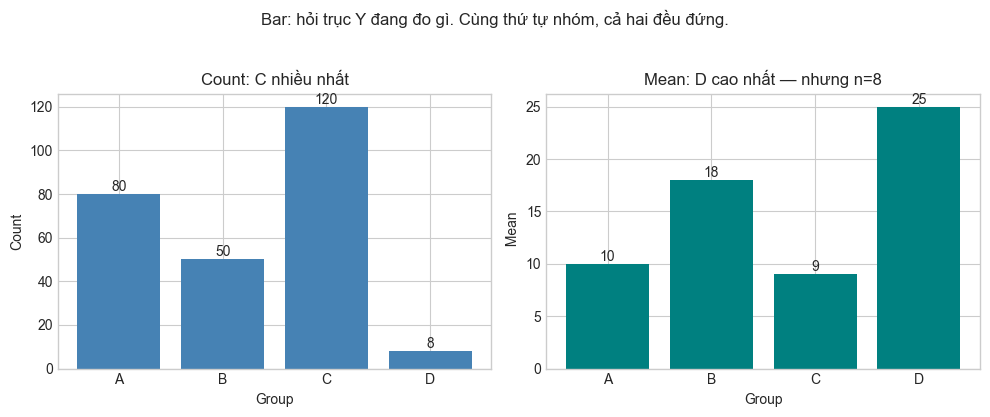

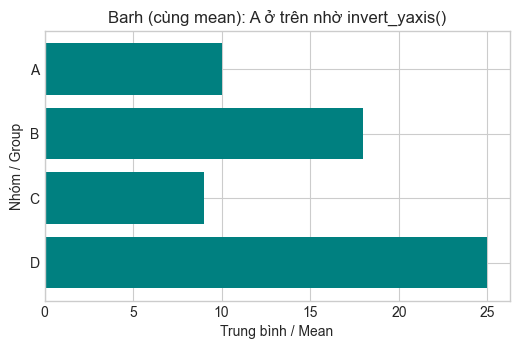

In [26]:
# Cùng thứ tự nhóm A–D. Hai panel = HAI loại số khác nhau (count vs mean).
nhom = ["A", "B", "C", "D"]
dem = np.array([80, 50, 120, 8])   # số quan sát
tb = np.array([10, 18, 9, 25])     # trung bình — D cao nhất nhưng n nhỏ

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(nhom, dem, color="steelblue")
axes[0].set(title="Count: C nhiều nhất", xlabel="Group", ylabel="Count")
axes[0].bar_label(axes[0].containers[0])

axes[1].bar(nhom, tb, color="teal")
axes[1].set(title="Mean: D cao nhất — nhưng n=8", xlabel="Group", ylabel=" Mean")
axes[1].bar_label(axes[1].containers[0])

fig.suptitle("Bar: hỏi trục Y đang đo gì. Cùng thứ tự nhóm, cả hai đều đứng.", y=1.03)
fig.tight_layout()
plt.show()

# barh: đảo trục y để A ở trên, khớp thứ tự đọc của bar đứng
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(nhom, tb, color="teal")
ax.invert_yaxis()
ax.set(title="Barh (cùng mean): A ở trên nhờ invert_yaxis()", xlabel="Trung bình / Mean", ylabel="Nhóm / Group")
plt.show()


**Đọc hình / How to read it**

* Panel count: **C** nhiều quan sát nhất, **D** rất ít (n=8).
* Panel mean: **D** trung bình cao nhất — **không** suy ra D “tốt/đắt nhất” nếu bỏ qua n.
* Hai bar **đứng**, cùng thứ tự A–B–C–D. `barh` nếu không `invert_yaxis()` sẽ để A ở **dưới**, dễ đọc ngược.

Count: C largest. Mean: D largest but tiny n. Keep category order consistent; invert `barh` so the first category is on top.


## 4. Histogram <a id="hist"></a>

Một **biến số**: x = giá trị, y = **tần suất** (bao nhiêu quan sát rơi vào khoảng / bin). Không cần groupby.

One numeric variable: x = value, y = **how often**. No groupby needed.

* **Lệch phải / right-skewed:** đỉnh lệch trái, đuôi dài sang phải
* **Lệch trái / left-skewed:** ngược lại
* **Đối xứng:** hai bên gần giống nhau
* **Nhiều đỉnh:** có thể trộn vài nhóm
* Cột cao sát **min/max:** có thể cắt trần/sàn, hoặc làm tròn
* `bins` quá ít = thô; quá nhiều = răng cưa — nhận xét **hình dạng tổng quát**


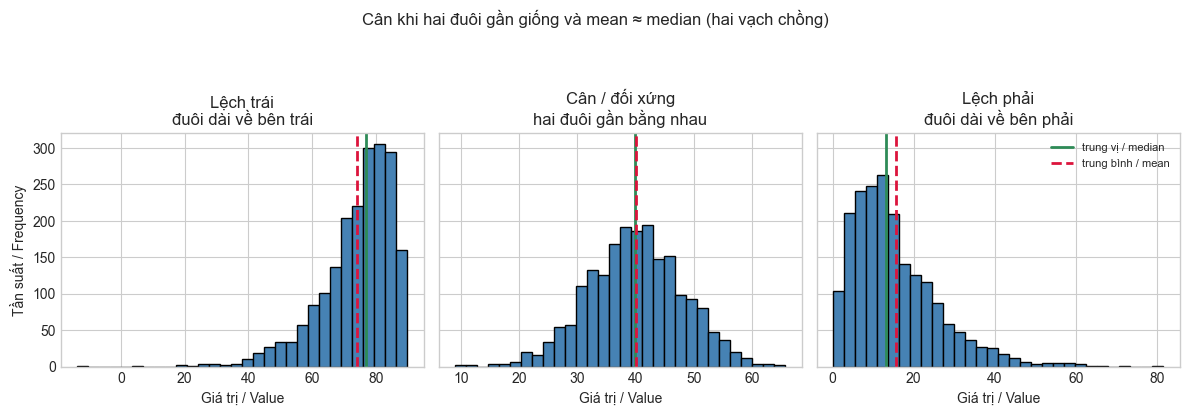

In [27]:
# Ba hình dạng + 2 vạch: trung vị (xanh) và trung bình (đỏ)
n = 2000
lech_trai = 90 - np.random.gamma(2.0, 8.0, n)
doi_xung = np.random.normal(40, 8, n)
lech_phai = np.random.gamma(2.0, 8.0, n)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
specs = [
    (lech_trai, "Lệch trái\nđuôi dài về bên trái"),
    (doi_xung, "Cân / đối xứng\nhai đuôi gần bằng nhau"),
    (lech_phai, "Lệch phải\nđuôi dài về bên phải"),
]
for ax, (data, title) in zip(axes, specs):
    ax.hist(data, bins=30, edgecolor="black", color="steelblue")
    med, mean = np.median(data), np.mean(data)
    ax.axvline(med, color="seagreen", lw=2, label="trung vị / median")
    ax.axvline(mean, color="crimson", lw=2, ls="--", label="trung bình / mean")
    ax.set(title=title, xlabel="Giá trị / Value")
axes[0].set_ylabel("Tần suất / Frequency")
axes[2].legend(fontsize=8, loc="upper right")

fig.suptitle("Cân khi hai đuôi gần giống và mean ≈ median (hai vạch chồng)", y=1.08)
fig.tight_layout()
plt.show()


**Nhìn hình để biết lệch hay cân**

1. Tìm **đỉnh** (cột cao nhất) — chỗ dữ liệu tập trung.
2. So **đuôi trái** và **đuôi phải** tính từ đỉnh:
   * hai đuôi gần bằng nhau → **cân / đối xứng**
   * đuôi phải dài hơn → **lệch phải**
   * đuôi trái dài hơn → **lệch trái**
3. Nhìn hai vạch: **trung vị** (xanh, liền) và **trung bình** (đỏ, nét đứt):
   * hai vạch **gần như trùng** → khá cân
   * trung bình bị **kéo về phía đuôi dài** → đang lệch (không cân)

Không cần đếm từng cột. Chỉ so độ dài hai đuôi và vị trí hai vạch.

**How to see balance:** compare tail length on each side of the peak. Balanced ≈ similar tails, and mean ≈ median. Skewed ≈ one long tail that pulls the mean away from the median.


### Nếu lệch thì “cân” bằng cách nào khi nhìn hình?

Histogram **không vẽ lại cho cân** nếu dữ liệu vốn lệch. Có hai hướng:

**A. Không đổi dữ liệu** — chỉ mô tả: “lệch phải, trung bình lớn hơn trung vị”. Nhiều biến (thu nhập, giá, lượt xem) vốn lệch; lệch không phải lúc nào cũng là lỗi.

**B. Đổi thang nhìn** — hay dùng khi lệch **phải** và mọi giá trị > 0: vẽ `log(x)` (hoặc `np.log1p(x)` nếu có số 0). Log **nén đuôi dài** bên phải, hình thường **tròn hơn / cân hơn**. Đó là đổi **cách nhìn**, không phải xóa lệch trong dữ liệu gốc.

Lệch trái ít gặp hơn; không dùng log cho số âm.

If it is right-skewed and all values are positive, a **log scale** (or histogram of `log(x)`) often looks more balanced. You are changing the scale, not deleting the skew from the raw data.


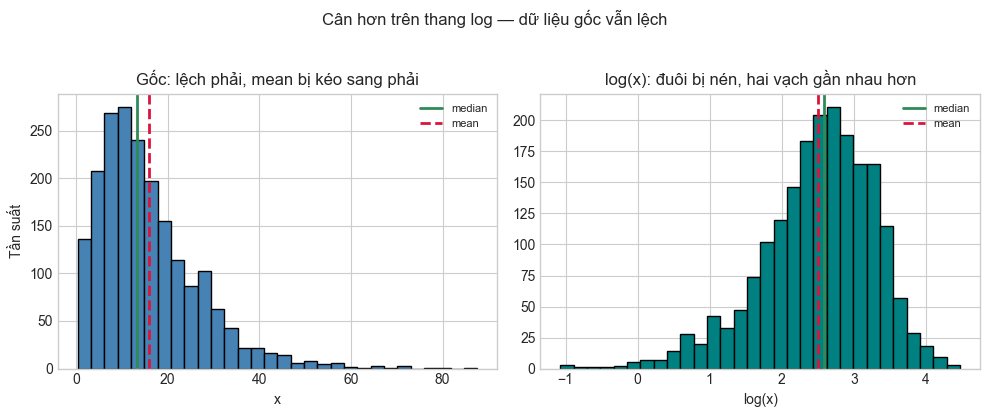

In [28]:
# Cùng một dữ liệu lệch phải: gốc vs log
lech_phai = np.random.gamma(2.0, 8.0, 2000)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(lech_phai, bins=30, edgecolor="black", color="steelblue")
axes[0].axvline(np.median(lech_phai), color="seagreen", lw=2, label="median")
axes[0].axvline(np.mean(lech_phai), color="crimson", lw=2, ls="--", label="mean")
axes[0].set(title="Gốc: lệch phải, mean bị kéo sang phải", xlabel="x", ylabel="Tần suất")
axes[0].legend(fontsize=8)

lx = np.log(lech_phai)  # mọi x > 0
axes[1].hist(lx, bins=30, edgecolor="black", color="teal")
axes[1].axvline(np.median(lx), color="seagreen", lw=2, label="median")
axes[1].axvline(np.mean(lx), color="crimson", lw=2, ls="--", label="mean")
axes[1].set(title="log(x): đuôi bị nén, hai vạch gần nhau hơn", xlabel="log(x)")
axes[1].legend(fontsize=8)

fig.suptitle("Cân hơn trên thang log — dữ liệu gốc vẫn lệch", y=1.03)
fig.tight_layout()
plt.show()


**Đọc cặp hình trên:** trái = chưa cân (đuôi phải dài, vạch đỏ lệch phải). Phải = cùng dữ liệu sau `log`, hai đuôi gần hơn và mean ≈ median hơn. Khi nhận xét, nói rõ đang nhìn **x gốc** hay **log(x)**.

Left: raw, unbalanced. Right: same values on a log scale, closer to balanced. Always say which scale you used.


## 5. Subplots <a id="subplots"></a>

Một figure, nhiều ô. Mỗi ô là một biểu đồ độc lập.

One figure, several panels. Each panel is its own plot.

1. Đọc **từng ô** bằng đúng loại hình (line / scatter / bar / hist ở trên).
2. Đọc **title và nhãn trục** của ô đó — đừng trộn x/y giữa các ô.
3. Hỏi: các ô **cùng một câu chuyện** hay nói các khía cạnh khác nhau?


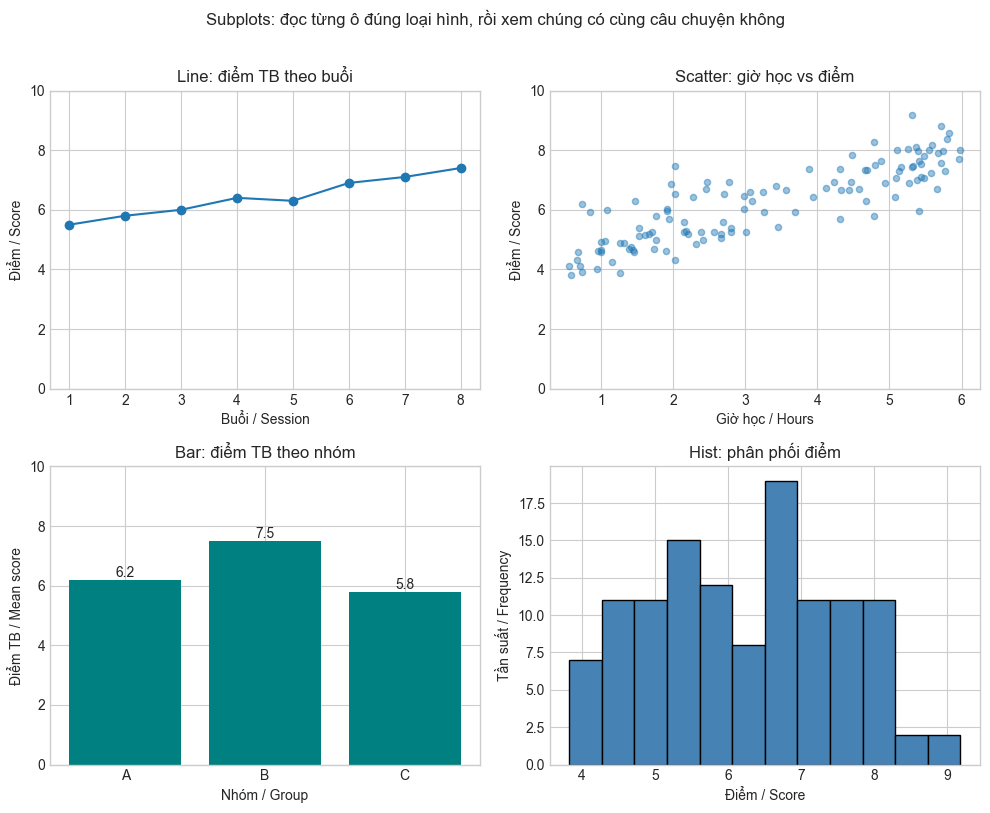

In [29]:
buoi = np.arange(1, 9)
diem_tb = np.array([5.5, 5.8, 6.0, 6.4, 6.3, 6.9, 7.1, 7.4])

gio_hoc = np.random.uniform(0.5, 6, 120)
diem = np.clip(4 + 0.7 * gio_hoc + np.random.normal(0, 0.7, 120), 0, 10)

nhom = ["A", "B", "C"]
tb_nhom = [6.2, 7.5, 5.8]

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

ax[0, 0].plot(buoi, diem_tb, marker="o")
ax[0, 0].set(title="Line: điểm TB theo buổi", xlabel="Buổi / Session", ylabel="Điểm / Score")
ax[0, 0].set_ylim(0, 10)

ax[0, 1].scatter(gio_hoc, diem, alpha=0.45, s=20)
ax[0, 1].set(title="Scatter: giờ học vs điểm", xlabel="Giờ học / Hours", ylabel="Điểm / Score")
ax[0, 1].set_ylim(0, 10)

ax[1, 0].bar(nhom, tb_nhom, color="teal")
ax[1, 0].set(title="Bar: điểm TB theo nhóm", xlabel="Nhóm / Group", ylabel="Điểm TB / Mean score")
ax[1, 0].set_ylim(0, 10)
ax[1, 0].bar_label(ax[1, 0].containers[0])

ax[1, 1].hist(diem, bins=12, edgecolor="black", color="steelblue")
ax[1, 1].set(title="Hist: phân phối điểm", xlabel="Điểm / Score", ylabel="Tần suất / Frequency")

fig.suptitle("Subplots: đọc từng ô đúng loại hình, rồi xem chúng có cùng câu chuyện không", y=1.01)
fig.tight_layout()
plt.show()


**Đọc hình / How to read it**

1. Line: điểm TB **tăng** theo buổi (có một nhịp hơi hạ).
2. Scatter: giờ học nhiều hơn thì điểm có xu hướng **cao hơn** (mây dương, còn rải).
3. Bar: nhóm **B** trung bình cao nhất.
4. Hist: điểm tập trung khoảng trung bình khá, không đối xứng hoàn hảo.

Sau đó hỏi: bốn ô có **cùng hướng** không? (học nhiều / theo thời gian / nhóm B → điểm cao hơn.) Đừng lấy trục của ô line gán cho ô hist.

Read each panel with its own rule, then ask whether they tell **one story**.


## 6. Khung viết nhận xét / Writing template <a id="khung"></a>

```
# 1. Tôi nhìn thấy: ... (hướng / nhóm cao nhất / lệch trái-phải / mây điểm)
# 2. Điều đó nói gì về biến đang xét: ...
# 3. Điểm lạ hoặc hạn chế: ... (ngoại lai, trần/sàn, n nhỏ, phân tán mạnh)
```

```
# 1. I see: ... (direction / tallest bar / skew / point cloud)
# 2. What it means for the variable of interest: ...
# 3. Odd pattern or limit: ... (outlier, cap/floor, tiny group, weak cloud)
```

**Tránh / Avoid:** “Tôi đã dùng `plt.plot`.” — mô tả code.

**Nên / Prefer:** “Y tăng theo X nhưng mây điểm rải, nên quan hệ cùng chiều nhưng không chặt.”

Áp khung này cho bài lab Matplotlib (hoặc bất kỳ hình nào): nhìn checklist đúng loại hình, rồi viết 3 câu.

Use this template on the Matplotlib lab (or any figure): pick the matching checklist, then write three sentences.
